In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

In [2]:
CITIES = np.array([
    [6734, 1453], [2233, 10], [5530, 1424], [401, 841], [3082, 1644],
    [7608, 4458], [7573, 3716], [7265, 1268], [6898, 1885], [1112, 2049],
    [5468, 2606], [5989, 2873], [4706, 2674], [4612, 2035], [6347, 2683],
    [6107, 669], [7611, 5184], [7462, 3590], [7732, 4723], [5900, 3561],
    [4483, 3369], [6101, 1110], [5199, 2182], [1633, 2809], [4307, 2322],
    [675, 1006], [7555, 4819], [7541, 3981], [3177, 756], [7352, 4506],
    [7545, 2801], [3245, 3305], [6426, 3173], [4608, 1198], [23, 2216],
    [7248, 3779], [7762, 4595], [7392, 2244], [3484, 2829], [6271, 2135],
    [4985, 140], [1916, 1569], [7280, 4899], [7509, 3239], [10, 2676],
    [6807, 2993], [5185, 3258], [3023, 1942]
])

OPTIMAL_SOLUTION = 35000.00

In [18]:
def set_seed(seed=42):
    random.seed(seed)           
    np.random.seed(seed)

In [3]:
def create_route(num_cities):
    return np.random.permutation(num_cities)

def calculate_distance(cities):
    num_cities = len (cities)
    distance_matrix = np.full((num_cities, num_cities), np.inf)
    for i in range(num_cities):
        for j in range(num_cities):
            distance_matrix[i, j] = np.linalg.norm(cities[i] - cities[j])
    return distance_matrix

def calculate_route_distance(route, distance_matrix):
    distance = 0
    for i in range(len(route) - 1):
        distance += distance_matrix[route[i], route[i + 1]]
    distance += distance_matrix[route[-1], route[0]]
    return distance

def selection_parents(next_generation):
    selected_parents = random.sample(next_generation, 2)
    return selected_parents[0], selected_parents[1]

In [4]:
def original_crossover(parent1, parent2):
    size = len(parent1)
    start, end = sorted(random.sample(range(size), 2))
    child = [None] * size
    child[start:end] = parent1[start:end]
    pointer = end

    for city in parent2:
        if city not in child:
            while child[pointer % size] is not None:
                pointer += 1
            child[pointer % size] = city
    return child

def original_mutate(child, mutation_rate):
    if random.random() < mutation_rate:
        i, j = random.sample(range(len(child)), 2)
        child[i], child[j] = child[j], child[i]
    return child

def build_edge_table(parent1, parent2):
    size = len(parent1)

    edge_table = {i: set() for i in range(size)}
    
    for p in [parent1, parent2]:
        for i in range(size):
            edge_table[p[i]].add(p[(i - 1) % size])
            edge_table[p[i]].add(p[(i + 1) % size])
    
    return edge_table

def proposed_crossover(parent1, parent2):
    size = len(parent1)
    edge_table = build_edge_table(parent1, parent2)
    child = []
    current_city = random.choice([parent1[0], parent2[0]])
    
    while len(child) < size:
        child.append(current_city)
        
        for neighbors in edge_table.values():
            neighbors.discard(current_city)    
            
        neighbors_of_current = edge_table[current_city]
        
        if neighbors_of_current:
            min_size = min(len(edge_table[n]) for n in neighbors_of_current)
            candidates = [n for n in neighbors_of_current if len(edge_table[n]) == min_size]
            next_city = random.choice(candidates)
        else:
            remaining_cities = [c for c in range(size) if c not in child]
            if remaining_cities:
                next_city = random.choice(remaining_cities)
            else:
                break
                
        current_city = next_city
        
    return child

def proposed_mutate(child, mutation_rate):
    if random.random() < mutation_rate:
        i, j = sorted(random.sample(range(len(child)), 2))
        child[i:j] = reversed(child[i:j])
    return child


In [20]:
def TSP_genetic_algorithm(cities, population_size=100, num_generations=2000, mutation_rate=0.2, stop_distance = OPTIMAL_SOLUTION, mode="original"):
    set_seed()
    distance_matrix = calculate_distance(cities) 
    population = [create_route(len(cities)) for _ in range(population_size)]

    for generation in range(num_generations):
        population = sorted(population, key=lambda route: calculate_route_distance(route, distance_matrix))

        if calculate_route_distance(population[0], distance_matrix) > stop_distance:
            next_generation = population[: population_size // 2]

            for _ in range(population_size // 2):
                parent1, parent2 = selection_parents(next_generation)
                child = original_crossover(parent1, parent2) if mode == "original" else proposed_crossover(parent1, parent2)
                next_generation.append(original_mutate(child, mutation_rate) if mode == "original" else proposed_mutate(child, mutation_rate))

            population = next_generation
        
        else:
            return population[0], calculate_route_distance(population[0], distance_matrix), generation
    
    best_route = population[0]
    
    return best_route, calculate_route_distance(best_route, distance_matrix), generation

In [21]:
mutation_rates = [0.2, 0.4, 0.6]
population_sizes = [100, 250, 500, 750, 1000]
results_original_algorithm = {m: [] for m in mutation_rates}
results_proposed_algorithm = {m: [] for m in mutation_rates}

for mutation_rate in mutation_rates:
    for population_size in population_sizes:
        _, _, generation = TSP_genetic_algorithm(CITIES, population_size=population_size, mutation_rate=mutation_rate)
        results_original_algorithm[mutation_rate].append(generation)

        _, _, generation = TSP_genetic_algorithm(CITIES, population_size=population_size, mutation_rate=mutation_rate, mode="proposed")
        results_proposed_algorithm[mutation_rate].append(generation)

In [9]:
colors = ['#E70C3C', "#1C71C7", "#BA06D6"]

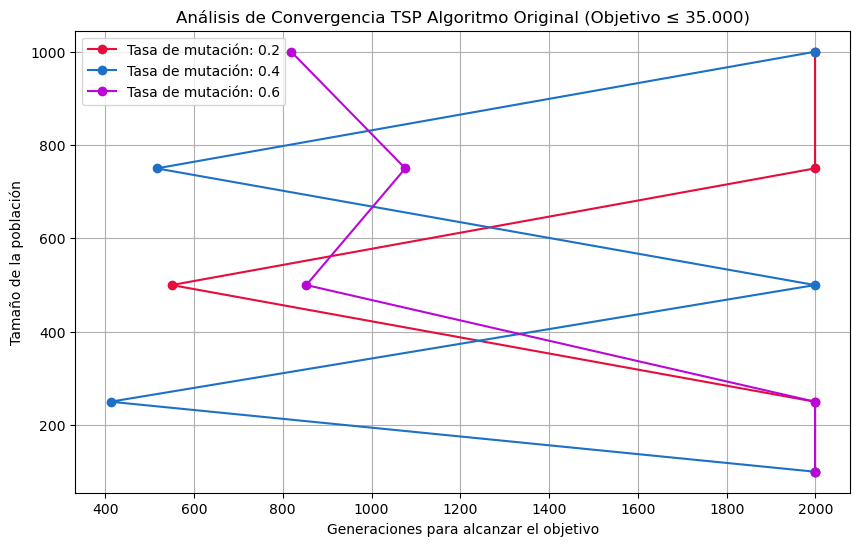

In [22]:
plt.figure(figsize=(10, 6))
for i, mutation_rate in enumerate(mutation_rates):
    plt.plot(results_original_algorithm[mutation_rate], population_sizes, marker='o', color = colors[i], label=f'Tasa de mutación: {mutation_rate}')

plt.xlabel('Generaciones para alcanzar el objetivo')
plt.ylabel('Tamaño de la población')
plt.title('Análisis de Convergencia TSP Algoritmo Original (Objetivo ≤ 35.000)')
plt.legend()
plt.grid(True)
plt.savefig('results/original_algorithm_tsp_convergence.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
plt.show()

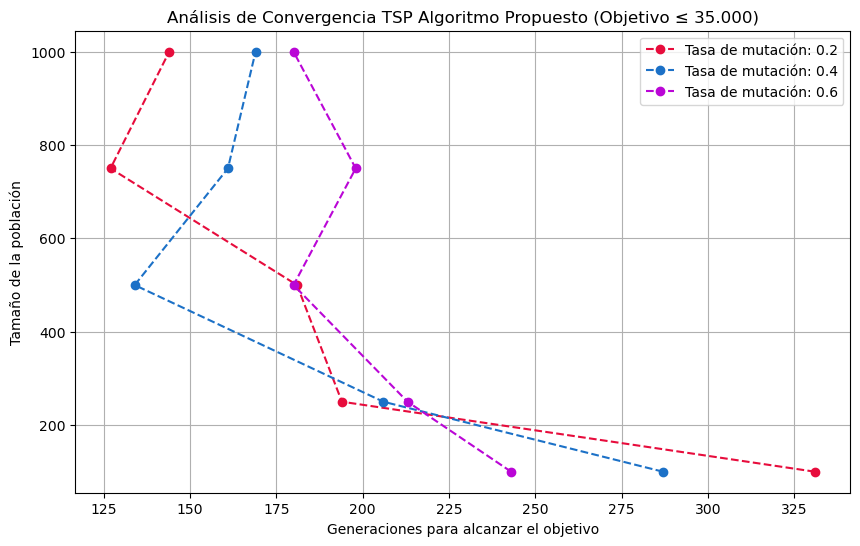

In [23]:
plt.figure(figsize=(10, 6))
for i, mutation_rate in enumerate(mutation_rates):
    plt.plot(results_proposed_algorithm[mutation_rate], population_sizes, marker='o', linestyle = "--", color = colors[i], label=f'Tasa de mutación: {mutation_rate}')

plt.xlabel('Generaciones para alcanzar el objetivo')
plt.ylabel('Tamaño de la población')
plt.title('Análisis de Convergencia TSP Algoritmo Propuesto (Objetivo ≤ 35.000)')
plt.legend()
plt.grid(True)
plt.savefig('results/proposed_algorithm_tsp_convergence.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
plt.show()


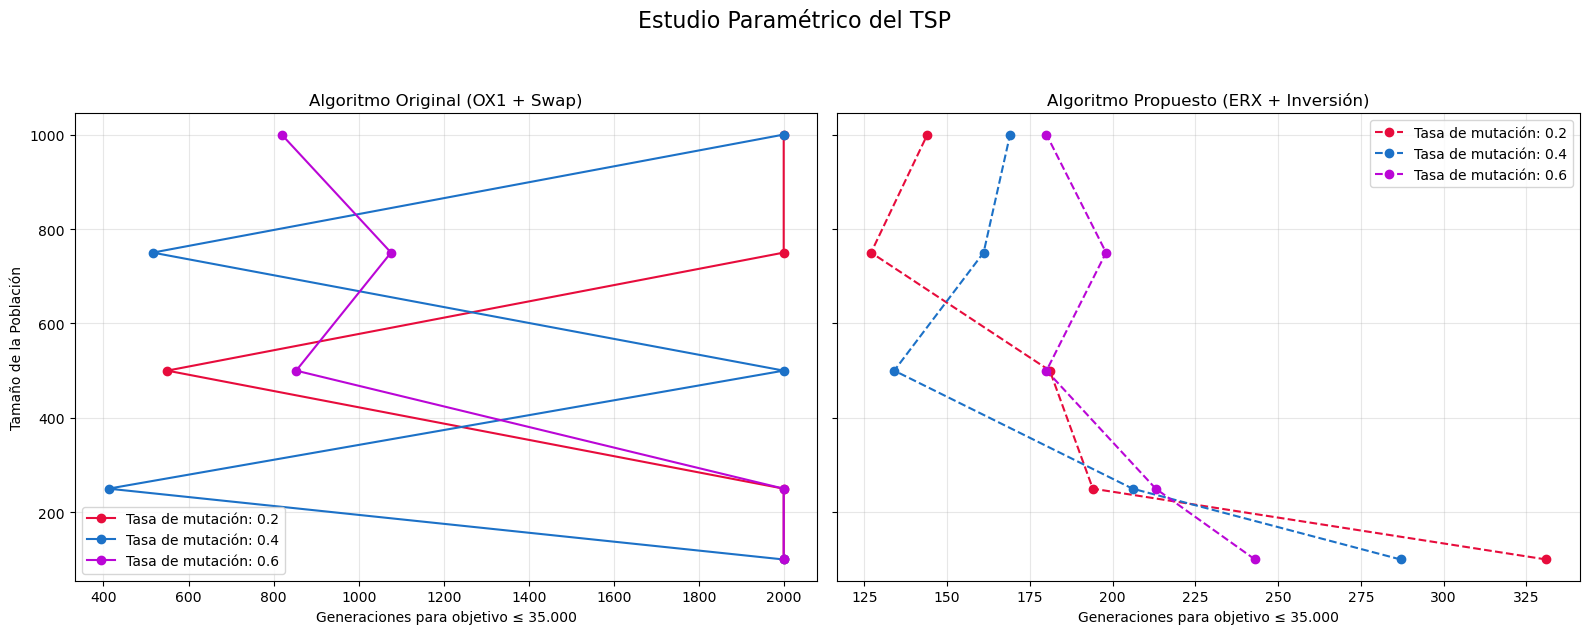

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, mutation_rate in enumerate(mutation_rates):
    ax1.plot(results_original_algorithm[mutation_rate], population_sizes, marker='o', linestyle='-', color = colors[i], label=f'Tasa de mutación: {mutation_rate}')

ax1.set_xlabel('Generaciones para objetivo ≤ 35.000')
ax1.set_ylabel('Tamaño de la Población')
ax1.set_title('Algoritmo Original (OX1 + Swap)')
ax1.legend()
ax1.grid(True, alpha=0.3)

for i, mutation_rate in enumerate(mutation_rates):
    ax2.plot(results_proposed_algorithm[mutation_rate], population_sizes, marker='o', linestyle='--', color = colors[i], label=f'Tasa de mutación: {mutation_rate}')

ax2.set_xlabel('Generaciones para objetivo ≤ 35.000')
ax2.set_title('Algoritmo Propuesto (ERX + Inversión)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('Estudio Paramétrico del TSP', fontsize=16, y=1.05)
plt.tight_layout()
plt.savefig('results/proposed_vs_original_algorithm_tsp_convergence.png', dpi=300, bbox_inches='tight', facecolor='white', transparent=False)
plt.show()